Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Training Set Evaluation:
RMSE: 3.12
MAE: 1.75
R² Score: 0.92

Test Set Evaluation:
RMSE: 4.05
MAE: 2.11
R² Score: 0.87


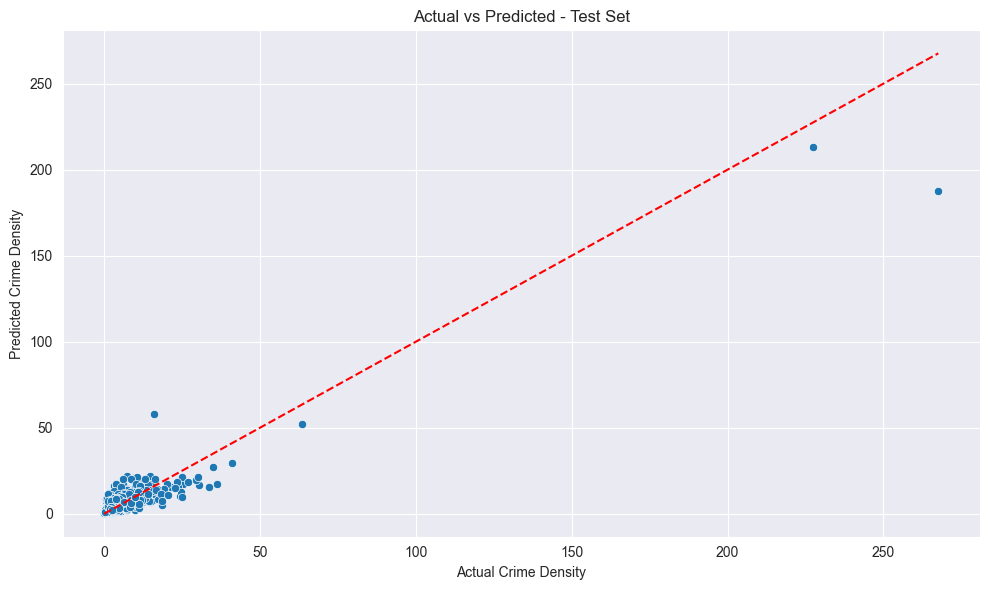

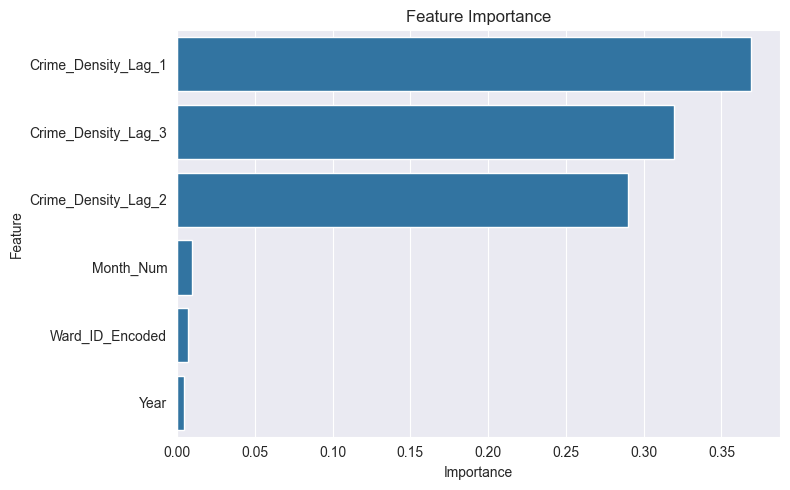

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
import os

# -----------------------------
# Get the absolute path to the file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one directory
file_path = os.path.join(parent_dir, "output_csv_files", "ward_temporal_analysis.csv")

# Load and prepare data
df = pd.read_csv(file_path, parse_dates=['Month'])
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df = df.dropna()

# Extract year and numeric month
df['Year'] = df['Month'].dt.year
df['Month_Num'] = df['Month'].dt.month

# Rename columns to remove spaces
df = df.rename(columns={'Ward ID': 'Ward_ID'})

# Create lag features
def create_lag_features(df, lag_periods=[1, 2, 3]):
    """
    Create lag features for crime density
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataframe with time series data
    lag_periods : list
        List of lag periods to create
    Returns:
    --------
    pandas DataFrame with added lag features
    """
    # Sort the dataframe by Ward_ID, Year, and Month_Num
    df = df.sort_values(['Ward_ID', 'Year', 'Month_Num'])
    
    # Create lag features for each ward separately
    for ward in df['Ward_ID'].unique():
        ward_mask = df['Ward_ID'] == ward
        for lag in lag_periods:
            df.loc[ward_mask, f'Crime_Density_Lag_{lag}'] = df.loc[ward_mask, 'Monthly_Crime_Density'].shift(lag)
    
    return df

# Create lag features
df_with_lags = create_lag_features(df)

# Encode Ward_ID
le = LabelEncoder()
df_with_lags['Ward_ID_Encoded'] = le.fit_transform(df_with_lags['Ward_ID'])

# Define features
lag_features = [f'Crime_Density_Lag_{lag}' for lag in [1, 2, 3]]
features = ['Ward_ID_Encoded', 'Year', 'Month_Num'] + lag_features

# Train-test split
df_train = df_with_lags[df_with_lags['Year'] <= 2024]
df_test = df_with_lags[df_with_lags['Year'] > 2024]

# Drop rows with NaN values in any of the features
df_train = df_train.dropna(subset=features + ['Monthly_Crime_Density'])
df_test = df_test.dropna(subset=features + ['Monthly_Crime_Density'])

X_train = df_train[features]
y_train = df_train['Monthly_Crime_Density']
X_test = df_test[features]
y_test = df_test['Monthly_Crime_Density']
# -----------------------------
# Grid Search for Hyperparameters
# -----------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Best Parameters: {grid.best_params_}")

# -----------------------------
# Predictions
# -----------------------------
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# -----------------------------
# Evaluation Metrics
# -----------------------------
def evaluate_model(y_true, y_pred, dataset_name=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Evaluation:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    return rmse, mae, r2

evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")

# -----------------------------
# Visualization
# -----------------------------

# 1. Actual vs Predicted (Test Set)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted - Test Set')
plt.xlabel('Actual Crime Density')
plt.ylabel('Predicted Crime Density')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Feature Importance
importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()
